In [6]:
#Step 1: Load & combine datasets
import pandas as pd

countries = {
    "Ethiopia": "../data/ethiopia_clean.csv",
    "Kenya": "../data/kenya_clean.csv",
    "Nigeria": "../data/nigeria_clean.csv",
    "Sudan": "../data/sudan_clean.csv",
    "Tanzania": "../data/tanzania_clean.csv"
}

dfs = []

for country, path in countries.items():
    df = pd.read_csv(path)
    df["Country"] = country
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

combined_df.head()
combined_df["Country"].value_counts()
#Check all countries:
combined_df["Country"].unique()
#Random sample:
combined_df.sample(10)
#Group preview:
combined_df.groupby("Country").head(2)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
4108,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
4109,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
8216,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
8217,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
12324,2015,1,25.18,35.55,16.14,19.41,0.00,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
12325,2015,2,23.92,34.14,15.81,18.33,0.00,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
16432,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
16433,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1


What this means for the Task 3

we are now in a very strong position:

✅ Data combined correctly
✅ Equal number of records
✅ Ready for fair comparison

In [7]:
dfs = []

for country, path in countries.items():
    print(f"Loading {country} from {path}")
    
    try:
        df = pd.read_csv(path)
        df["Country"] = country
        print(f"{country} loaded: {df.shape}")
        dfs.append(df)
    except Exception as e:
        print(f"Error loading {country}: {e}")

Loading Ethiopia from ../data/ethiopia_clean.csv
Ethiopia loaded: (4108, 15)
Loading Kenya from ../data/kenya_clean.csv
Kenya loaded: (4108, 15)
Loading Nigeria from ../data/nigeria_clean.csv
Nigeria loaded: (4108, 15)
Loading Sudan from ../data/sudan_clean.csv
Sudan loaded: (4108, 15)
Loading Tanzania from ../data/tanzania_clean.csv
Tanzania loaded: (4108, 15)


This one is more Strong debugging version od data loadng for combined datasets

In [13]:
combined_df.columns

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Date', 'Month'],
      dtype='str')

In [15]:
combined_df.columns = combined_df.columns.str.strip().str.upper()

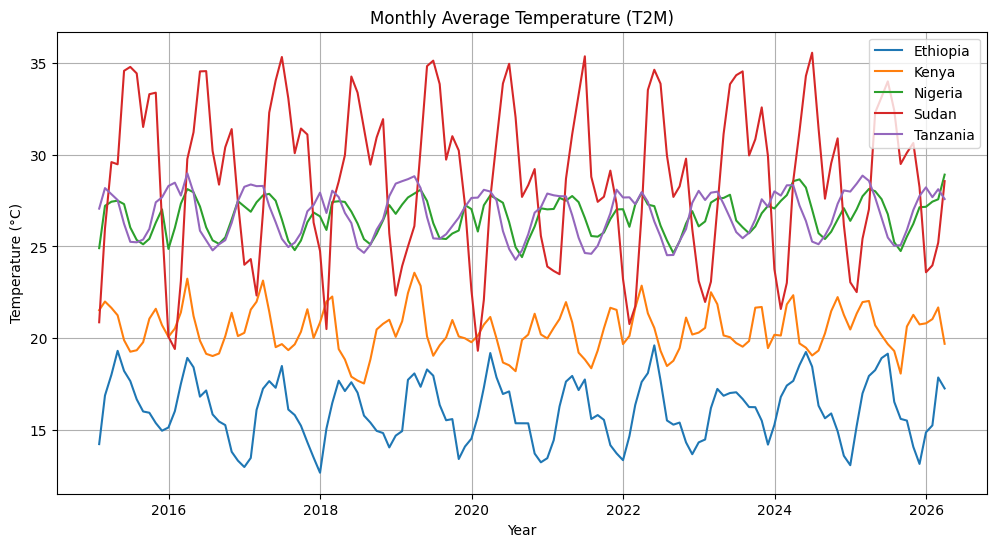

In [22]:
import matplotlib.pyplot as plt

combined_df["DATE"] = pd.to_datetime(combined_df["DATE"])

monthly_temp = combined_df.groupby(
    ["COUNTRY", pd.Grouper(key="DATE", freq="ME")]
)["T2M"].mean().reset_index()

plt.figure(figsize=(12,6))

for country in monthly_temp["COUNTRY"].unique():
    subset = monthly_temp[monthly_temp["COUNTRY"] == country]
    plt.plot(subset["DATE"], subset["T2M"], label=country)

plt.legend()
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

Temperature Trend Insights

- All countries exhibit strong seasonal temperature cycles, indicating consistent climatic patterns over time.
- Sudan records the highest temperatures and the largest variability, suggesting increased exposure to extreme heat conditions.
- Ethiopia shows the lowest temperature range, likely influenced by its higher altitude, indicating relatively lower heat stress.
- Nigeria and Tanzania demonstrate moderate and stable temperature patterns, though slight upward trends suggest gradual warming.
- Overall, there is evidence of increasing temperature peaks in recent years, pointing toward a regional warming trend.

These findings highlight varying levels of climate exposure across countries, with Sudan appearing most vulnerable to heat-related climate risks.

In [26]:
temp_summary = combined_df.groupby("COUNTRY")["T2M"].agg(
    ["mean", "median", "std"]
)

temp_summary

,mean,median,std
COUNTRY,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


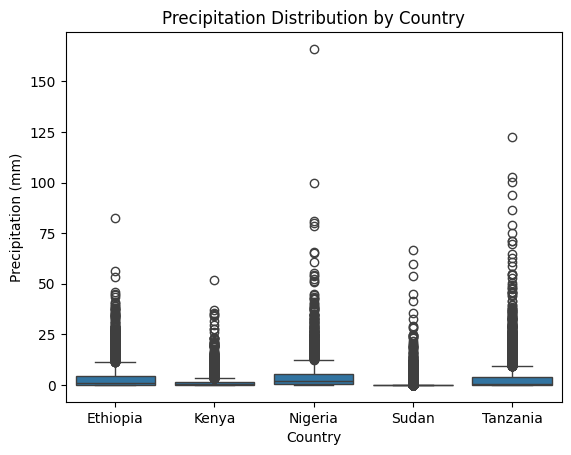

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=combined_df, x="COUNTRY", y="PRECTOTCORR")

plt.title("Precipitation Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Precipitation (mm)")
plt.show()

## Precipitation Variability Insights

- All countries exhibit highly skewed precipitation distributions, with most days receiving little to no rainfall and occasional extreme events.
- Nigeria and Tanzania show the greatest variability in precipitation, indicating unstable and unpredictable rainfall patterns.
- Nigeria records the most extreme rainfall events, suggesting a high risk of flooding.
- Sudan and Kenya have the lowest median precipitation levels, indicating persistent dry conditions and higher drought vulnerability.
- Ethiopia demonstrates moderate precipitation levels and variability, suggesting exposure to both drought and occasional heavy rainfall events.

These patterns highlight significant differences in climate risk profiles across countries, particularly between drought-prone and flood-prone regions.